---
title: Comparing SWOT HR Elevation to ICESat-2
thumbnail: ../img/swot.png
date: 2026-05-14
github: https://github.com/cryointhecloud/CryocloudWebsite
subject: Tutorial
authors:
  - name: Zachary Katz
    affiliations:
      - id: CSM
        institution: Colorado School of Mines
        department: Department of Geophysics
    email: zachary_katz@mines.edu
    corresponding: true
    github: zsk4
    orcid: 0009-0006-2779-7103
  - name: Tasha Snow
    affiliations:
      - University of Maryland
      - NASA Goddard Space Flight Center
      - CSM
    email: tsnow03@umd.edu
    orcid: 0000-0001-5697-5470
license: MIT
---

# Overview

In this tutorial, we will plot NASA/CNES's Surface Water and Ocean Topography (SWOT) High Rate (HR) and Low Rate (LR) coverage over Antarctica, then compare SWOT HR raster elevations to NASA’s Ice, Cloud, and Land Elevation Satellite-2 (ICESat-2) ATL06 land ice elevations over the Bach Ice Shelf (Antarctic Peninsula), verifying correct application of geophysical corrections. 

::::{admonition} Learning Objectives
:class: tip

By the end of this tutorial, you will be able to:

- Plot SWOT Low Rate (LR) and High Rate (HR) availability over Antarctica  
- Obtain spatially coincident ICESat-2 ATL06 land ice and SWOT HR raster elevations
- Correct for differing geophysical corrections between missions  
- Correct for ice advection between acquisitions  
- Plot a comparison of ICESat-2 and SWOT elevations over Bach Ice Shelf
::::

::::{important} Prerequisites
- [SWOT HR data access tutorial](https://book.cryointhecloud.com/swot-hr-access)
- A free [**Earthdata Login**](https://urs.earthdata.nasa.gov/) to download SWOT and ICESat-2 data
- (Optional) Your Earthdata login can be stored for programattic access by following the CryoCloud [**Configure Programmatic Access To NASA Servers**](https://book.cryointhecloud.com/earthdata/#configure-programmatic-access-to-nasa-servers) how-to guide.
- This notebook requires ~800 MB of memory to run.
::::

# Visualize SWOT coverage over Antarctica
Building on the previous [**SWOT HR data access tutorial**]() where we learned how to find and open SWOT data, we’ll now focus on determining what SWOT HR and LR coverage exists over Antarctica for our comparison to ICESat-2. In this step, you’ll create an interactive map of SWOT coverage over Antarctica.

:::{hint} What you’ll do
1. Ensure required packages and local data folders exist  
2. Retrieve or reuse local copies of:
   - **Scripps Antarctica polygons** (grounded ice / ice shelves)
   - **SWOT HR seasonal KML** (culled to south of 60°S)
   - **SWOT LR orbit KMZ**  
3. Reproject to South Polar Stereographic (EPSG:3031)  
4. Plot a data availability map
:::

::::{seealso} Data sources used
**SWOT orbit files**
- **SWOT HR Nominal Mask (Northern Hemisphere summer 2025 KML)** — from [PO.DAAC](https://podaac.jpl.nasa.gov/SWOT-events/SWOT_events.html)  \
  <https://podaac.jpl.nasa.gov/SWOT-events/swot_science_hr_Mar2025-v10_perPass.kml>  
  *Note:* PO.DAAC also publishes other HR masks; feel free to swap in a newer/older KML as desired.
- **SWOT LR orbit (KMZ)** — from [AVISO/CNES](https://www.aviso.altimetry.fr/en/missions/current-missions/swot/orbit.html) \
  <https://www.aviso.altimetry.fr/fileadmin/documents/missions/Swot/swot_science_orbit_sept2015-v2_10s.kmz>

**Other data**
- **Scripps Antarctica polygons** — from the supplement of [M.A. Depoorter et al., 2013](https://doi.pangaea.de/10.1594/PANGAEA.819147) \
<https://doi.pangaea.de/10013/epic.42133.d001>
::::

:::{note} On KML/KMZ Files
:class: dropdown
The orbit files are hosted in different locations and as different file types; because this tutorial downloads the orbit files directly from the source locations, the HR comes as a KML and LR orbit as a KMZ. A KMZ file is just a zipped version of KML that can typically be read by the same programs designed to read KML files (e.g., Fiona, Google Earth).
:::

## Package imports and data paths needed to get started

In [1]:
%matplotlib widget

from pathlib import Path
import io, zipfile, tempfile, os
import warnings
import requests
import fiona
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch
import cartopy.crs as ccrs

# Quiet noisy driver warnings (optional)
warnings.filterwarnings("ignore", message=".*ERROR parsing kml Style: No id.*", category=RuntimeWarning)

In [2]:
# --- Paths ---

# Make DATADIR, a folder to hold downloaded datasets
DATADIR = Path("/home/jovyan/shared/SWOT/data")  # adjust if needed, e.g., running locally
DATADIR.mkdir(parents=True, exist_ok=True)

# CryoCloud file targets
GL_SHP = DATADIR / "Antarctica_masks" / "scripps_antarctica_polygons_v1.shp" # Basemap
HR_KML = DATADIR / "hr_Mar2025_below60S.kml"   # HR KML
LR_KMZ = DATADIR / "lr_Sept2015.kmz"           # LR KMZ

# Source URLs [Try replacing with different versions]
HR_URL = "https://podaac.jpl.nasa.gov/SWOT-events/swot_science_hr_Mar2025-v10_perPass.kml" 
LR_URL = "https://www.aviso.altimetry.fr/fileadmin/documents/missions/Swot/swot_science_orbit_sept2015-v2_10s.kmz"

# Scripps polygons zip (contains multiple shapefile components)
GL_ZIP_URL = "https://doi.pangaea.de/10013/epic.42133.d001"

# Bach Ice Shelf bounding box location in South Polar Stereographic [ESPG: 3031]
bach = [-1920000, 480000, -1740000, 680000]

::::{tip} Data read-in helper functions
:class: tip
- `download_bytes` Robust HTTP downloads with timeouts
- `ensure_scripps_polygons` Fetches and unzips the Scripps shapefiles if missing
- `read_all_kml_layers` Merges all non-empty KML/KMZ layers into one GeoDataFrame
- `save_kml` Writes a KML for quick reuse
::::

In [3]:
# --- Data read-in elper functions ---
def download_bytes(url: str) -> bytes:
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    return r.content

def ensure_scripps_polygons(gl_shp_path: Path, source_zip_url: str) -> None:
    """Download & extract the Scripps Antarctica polygons if missing."""
    if gl_shp_path.exists():
        return
    gl_shp_path.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading Scripps Antarctica polygons…")
    content = download_bytes(source_zip_url)
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        zf.extractall(gl_shp_path.parent)
    print(f"Extracted to: {gl_shp_path.parent}")

def read_all_kml_layers(path: Path, driver="KML") -> gpd.GeoDataFrame:
    """Load all non-empty KML/KMZ layers into a single GeoDataFrame."""
    layers = fiona.listlayers(str(path))
    frames = []
    for lyr in layers:
        try:
            gdf = gpd.read_file(path, driver=driver, layer=lyr)
            if not gdf.empty:
                frames.append(gdf)
        except Exception as exc:
            print(f"Skipped layer '{lyr}': {exc}")
    if not frames:
        raise RuntimeError(f"No valid layers in {path}")
    return gpd.GeoDataFrame(pd.concat(frames, ignore_index=True))

def save_kml(gdf: gpd.GeoDataFrame, out_path: Path) -> None:
    """Save a GeoDataFrame as KML (for future reuse)."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    gdf.to_file(out_path, driver="KML")

::::{tip} Read the Scripps Antarctic basemap
- Auto download the file if not already present (We did this for you on CryoCloud, but provide code for re-download or local use).
- Load the Scripps polygons and reproject to EPSG:3031.  
- Split **grounded ice** and **ice shelves** for map styling.
::::

In [4]:
# Ensure basemap (Scripps polygons) is available
ensure_scripps_polygons(GL_SHP, GL_ZIP_URL)

# Load and prep Scripps polygons
gl_gdf = gpd.read_file(GL_SHP)
# Reproject to EPSG:3031 (Antarctic Polar Stereographic)
gl_gdf_3031 = gl_gdf.to_crs(epsg=3031)

# Split polygons containing grounded ice vs ice shelves
name_field = "Id_text" if "Id_text" in gl_gdf_3031.columns else None
if name_field is None:
    # Fall back to plotting all polygons uniformly if classification is missing
    grounded_3031 = gl_gdf_3031
    shelves_3031 = gpd.GeoDataFrame(geometry=[])
else:
    # Split polygons by class
    grounded_classes = {"Grounded ice or land", "Isolated island", "Ice rise or connected island"}
    grounded_3031 = gl_gdf_3031[gl_gdf_3031[name_field].isin(grounded_classes)]
    shelves_3031  = gl_gdf_3031[gl_gdf_3031[name_field] == "Ice shelf"]

::::{tip} Ensure culled HR coverage file exists

We cull the HR mask south of 60°S to speed up plotting by removing HR regions not relevant to Antarctica (We already did this for you on CryoCloud, but provide code for trying different versions of the HR mask). 

- Download the HR orbital file to a temporary location where it deletes as soon as we leave the for loop, minimizing memory usage
- Remove nadir features to only show swath coverage
- Save the culled HR KML locally as `hr_Mar2025_below60S.kml` so the next run is instant
::::
:::{note .dropdown} On culling the HR mask
We are able to cull the HR mask to below 60°S because each segment of HR data is discontinuous from other segments even if they are part of the same pass, resulting in the ability to filter for segments using bounding box criteria. Because the LR orbit file is split by pass, each pass contains data below 60°S and cannot easily be culled in the same way. If you run the culling yourself it can take ~20 minutes on CryoCloud.
:::


In [5]:
# --- Ensure SWOT HR coverage (culled to south of 60S) exists in CryoCloud ---
# Note: This process takes ~20 min if not already completed
if not HR_KML.exists():
    for url in HR_URLS:
        try:
            # Download HR orbital file into temp
            print(f"Trying HR KML: {url}")
            with tempfile.TemporaryDirectory() as tdir:
                kml_path = Path(tdir) / "hr.kml"
                kml_path.write_bytes(download_bytes(url))
            
                hr_all = read_all_kml_layers(kml_path, driver="KML") # with some KMZ/KML may need to use driver="LIBKML"
                hr_all = hr_all.assign(miny=hr_all.geometry.bounds.miny)
                # Cull below 60 S
                hr_south = hr_all[hr_all["miny"] < -60].drop(columns=["miny"])
                if "Name" in hr_south.columns:
                    # Remove nadir coverage to keep only KaRIn's
                    hr_south = hr_south[~hr_south["Name"].str.contains("Nadir", na=False)]
                save_kml(hr_south, HR_KML)
            print(f"Saved culled HR KML: {HR_KML}")
            break
        except Exception as exc:
            print(f"Failed HR download/parse from {url}: {exc}")
    else:
        raise RuntimeError("Could not obtain a usable SWOT HR KML.")


::::{tip} Ensure LR Coverage File Exists
- The LR orbit is provided as KMZ. Most environments can read it via driver `"KML"`.  
::::

In [6]:
# --- Ensure SWOT LR orbit exists in CryoCloud ---
if not LR_KMZ.exists():
    print("Downloading SWOT LR KMZ…")
    LR_KMZ.write_bytes(download_bytes(LR_URL))
    print(f"Saved: {LR_KMZ}")

::::{admonition} Load and reproject
:class: tip
- We merge all HR and LR layers, and reproject both HR and LR GeoDataFrames to **EPSG:3031**, the same projection as the Scripps Antarctic basemap.
- Loading takes ~6 min because the LR file contains all 584 SWOT passes!
::::

In [7]:
# --- Load HR/LR coverages and reproject to EPSG:3031 ---

# HR (already culled), stored as KML
hr_gdf = read_all_kml_layers(HR_KML, driver="KML")
hr_3031 = hr_gdf.to_crs(epsg=3031)

# LR, stored as KMZ  
lr_gdf = read_all_kml_layers(LR_KMZ, driver="KML")
if "Name" in lr_gdf.columns:
    lr_gdf = lr_gdf[~lr_gdf["Name"].str.contains("Nadir", na=False)]
lr_3031 = lr_gdf.to_crs(epsg=3031)

len(hr_3031), len(lr_3031)

(194, 584)

::::{tip} Plot coverage map
- Basemap: Grounded ice in gray and ice shelves in light gray
- **SWOT LR** is shown in red; **SWOT HR** in blue
- South Polar Stereographic is used for display and map is clipped to show Antarctica
::::

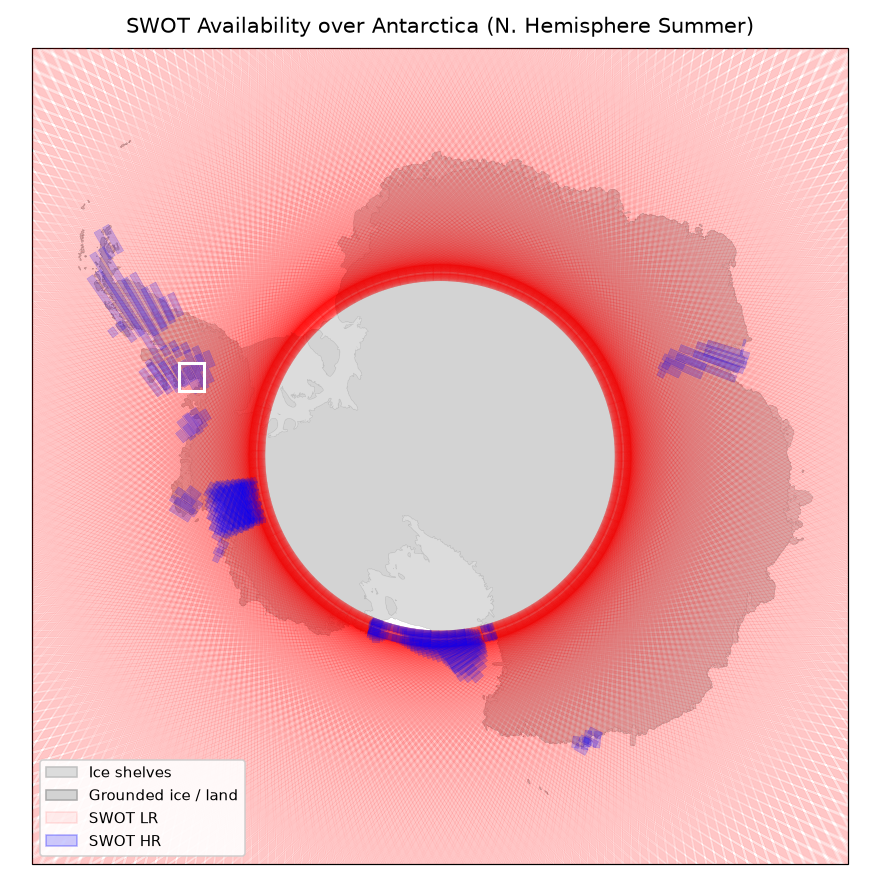

In [8]:
# --- Plot availability over Antarctica (EPSG:3031) ---
ps71 = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)

fig = plt.figure(figsize=(8, 8), dpi=110)
ax = plt.axes(projection=ps71)

# Antarctica basemap: grounded vs shelves
grounded_3031.plot(ax=ax, transform=ps71, color="lightgray", edgecolor="darkgray", linewidth=0.3, zorder=1)
shelves_3031.plot(ax=ax,   transform=ps71, color="gainsboro", edgecolor="silver", linewidth=0.25, zorder=2)

# SWOT LR (red), SWOT HR (blue)
# Build colors with different transparency for facecolor and edgecolor
swot_hr_fill  = to_rgba("blue", alpha=0.20)
swot_hr_edge  = to_rgba("blue", alpha=0.30)
swot_lr_fill  = to_rgba("red", alpha=0.06)
swot_lr_edge  = to_rgba("red", alpha=0.10)

# Note: Many HR/LR geometries are polygons; we use both facecolor and edgecolor lightly
lr_3031.plot(ax=ax, transform=ps71, color=swot_lr_fill, edgecolor=swot_lr_edge, linewidth=0.2, zorder=3)
hr_3031.plot(ax=ax, transform=ps71, color=swot_hr_fill, edgecolor=swot_hr_edge, linewidth=0.2, zorder=4)

bach_rect = plt.Rectangle((bach[0], bach[1]), bach[2] - bach[0], bach[3] - bach[1], 
                          zorder=5, linewidth=2, edgecolor="white", facecolor="none")
ax.add_patch(bach_rect)

# Crop axes to Antarctica
ax.set_xlim(-3000000, 3000000) # 3000 km2
ax.set_ylim(-3000000, 3000000)

legend_handles = [
    Patch(facecolor="gainsboro", edgecolor="silver", label="Ice shelves"),
    Patch(facecolor="lightgray", edgecolor="darkgray", label="Grounded ice / land"),
    Patch(facecolor=swot_lr_fill, edgecolor=swot_lr_edge, label="SWOT LR"),
    Patch(facecolor=swot_hr_fill, edgecolor=swot_hr_edge, label="SWOT HR"),
]
leg = ax.legend(handles=legend_handles, loc="lower left", frameon=True, framealpha=0.9)
for text in leg.get_texts():
    text.set_fontsize(10)

ax.set_title("SWOT Availability over Antarctica (N. Hemisphere Summer)", fontsize=14, pad=10)

plt.tight_layout()
plt.show()

:::{tip} Summary
We can see that HR coverage is limited to certain regions around Antarctica, while LR coverage is extensive to 78$\degree$ south, and also covers HR regions. In the next tutorials, we will focus on the Bach Ice Shelf region and compare HR data with ICESat-2 surface elevations, and then HR data with LR data.   
:::